# Agglomerative (Hierarchical) Clustering

## Table of Contents

### 1. What is Agglomerative Clustering?

### 2. Agglomerative Clustering in Scikit-Learn

### 3. Evaluation of Clustering

### 4. Important Considerations for Agglomerative Clustering

## 1. What is Agglomerative Clustering?

A hierarchical clustering method that builds a tree (dendrogram) of clusters.

“Agglomerative” means bottom-up:

- Start with each point as its own cluster

- Iteratively merge the two closest clusters

- Repeat until all points are merged into one cluster or a desired number of clusters is reached

Result: a dendrogram (tree diagram showing cluster merges)

Goal: Understand **hierarchical relationships** between data points.

**Unlike K-Means, it does not require random initialization, so results are deterministic given the same parameters**


## 2. Agglomerative Clustering in Scikit-Learn

The name of the class for Agglomerative Clustering in Scikit-Learn
  **sklearn.cluster.AgglomerativeClustering**


## **AgglomerativeClustering Parameters Explained (scikit-learn)**

### **Most Important Parameters**

### `1. n_clusters`
-  The number of clusters to form. Determines how many groups the algorithm will merge the points into.  
- default=2
- If you also set `distance_threshold`, this parameter is ignored because merging is stopped based on distance rather than cluster count.  

### `2.metric`

Distance metric used to calculate similarity between points. Determines which points are “close” to each other.

**Common Options:**  
  - `euclidean` (default) → straight-line distance; most common for numeric features.  
  - `manhattan` → sum of absolute differences; robust to outliers.  
  - `cosine` → measures angle between vectors; useful for text embeddings   

### `3. linkage`

Determines how the distance between **clusters** is computed during merging  

**Options**  

  - `ward` (default) → merges clusters that **minimize the variance** of combined cluster; produces compact, round clusters. Only works with Euclidean distance

  - `complete` → distance = **maximum distance** between any two points across clusters. Produces **tight, well-separated clusters**

  - `average` → distance = **average of all pairwise distances** between points in the two clusters. Balanced behavior between single and complete linkage

Different linkages affect **cluster shape, size and sensitivity to noise**  




**Important rules and constraints:**
- If `linkage="ward"`, **only `"euclidean"` is allowed**  
  (because Ward’s method relies on variance minimization).

Choice of metric affects which points are considered “close” and thus which clusters are merged first  


### **Occasionally Used Parameters**

### `distance_threshold`

Stops merging clusters when the distance between clusters exceeds this threshold.

**Options:** float (default=None)  

- Useful when you want a **hierarchy** and do not know the number of clusters in advance

- Example: `distance_threshold=5` → any clusters separated by more than 5 units will **not merge**, creating more clusters automatically

- If set, `n_clusters` is ignored  


### `compute_full_tree`

Determines whether the full clustering tree is computed. Needed for dendrogram plotting.  

**Options**  (default=auto)
  - `auto` → computes full tree only when needed (e.g., small datasets or dendrogram)
  - `True` → always compute the full tree; useful for plotting dendrograms  
  - `False` → skips computing full tree to save memory and computation for large datasets

### Apply Agglomerative Clustering to a simple Dataset

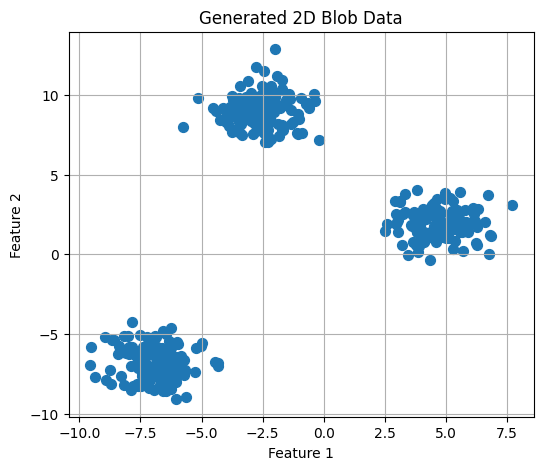

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
import pandas as pd
from sklearn.metrics import silhouette_score

# Generate 400 points in 2D, 3 clusters
X, y = make_blobs(n_samples=400, n_features=2, centers=3, random_state=42)

# Plot the raw data
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], s=50)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Generated 2D Blob Data")
plt.grid(True)
plt.show()

Silhouette Score: 0.8458787585795497


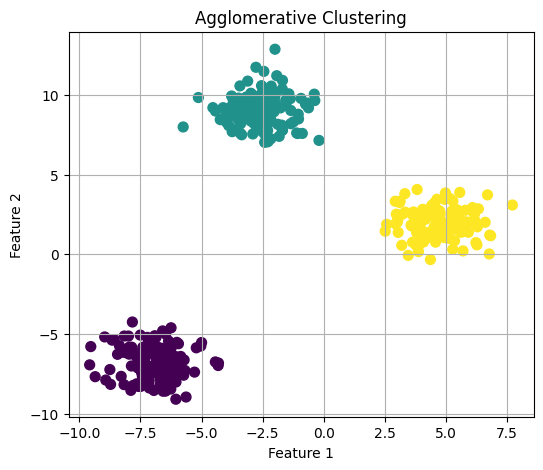

In [47]:
# Create the model
agg = AgglomerativeClustering(
    n_clusters=3,       # we know 3 clusters exist
    metric='euclidean',  # distance metric
    linkage='ward'          # linkage method
)

# Fit and predict cluster labels
labels = agg.fit_predict(X)
score = silhouette_score(X, labels)
print("Silhouette Score:", score)
# Plot clustered data
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis', s=50)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Agglomerative Clustering")
plt.grid(True)
plt.show()

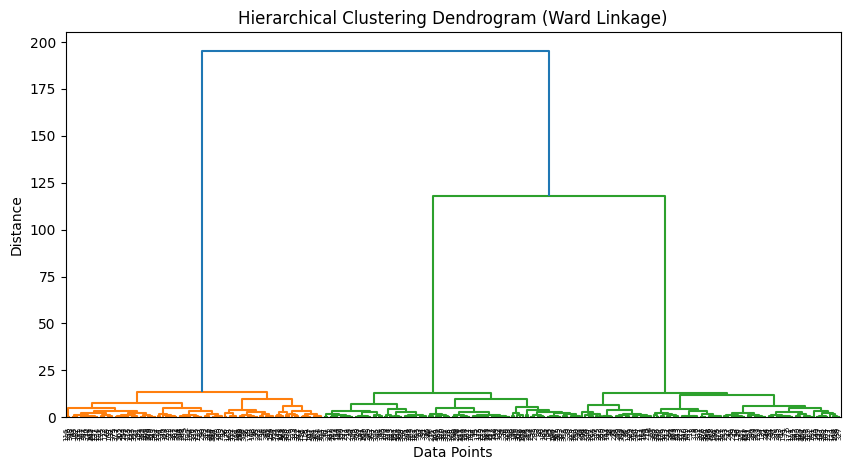

In [48]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

Z = linkage(X, method='ward', metric='euclidean')

# Plot dendrogram
plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

#### How to Interpret the Dendrogram

- Each leaf → one data point

- Each merge → two clusters being combined

- The height of a merge → distance between clusters

#### Choosing the Number of Clusters

- Draw a horizontal line across the dendrogram

- Count how many vertical branches it cuts

### Rule of thumb:

Choose the cut where there is a large vertical gap
(big jump in distance before clusters merge)

## Important Considerations for Agglomerative Clustering

### When to Use Agglomerative Clustering

**- Does not require specifying K upfront:**  
Hierarchical clustering can build a full hierarchy of clusters and allows you to decide the number of clusters later by cutting the dendrogram at a chosen level.

**- Works well with small to medium datasets:**  
Because it computes distances between many pairs of points, it is more suitable when the dataset is not extremely large.

**- Useful for understanding data structure:**  
The dendrogram provides a visual explanation of how data points are grouped, making it useful for exploratory analysis.

**- Flexible cluster shapes (linkage):**  
Different linkage methods allow the algorithm to capture different types of cluster structures


### Limitations of Agglomerative Clustering

**- Computationally expensive:**  
Agglomerative clustering has higher time and memory complexity, making it impractical for very large datasets

**- Sensitive to noise and outliers:**  
Outliers can form their own clusters or distort the merging process

**- Early decisions cannot be undone:**  
Once two clusters are merged, the algorithm cannot reconsider that decision later, which may lead to suboptimal clusters

**- Results depend heavily on linkage choice:**  
Different linkage methods can produce very different clusterings, so parameter selection is critical

## Task 2A: Agglomerative Clustering

In this task, you will apply **Agglomerative Clustering** to `CC GENERAL` dataset and follow **the same methodology** used in the previous clustering lab

## **1. Exploratory Data Analysis (EDA)**

In [49]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [50]:
df = pd.read_csv(
    r"C:\Users\ganna\Downloads\GUC_2350_68_65247_2026-02-25T11_06_51\CC GENERAL.csv"
)
print(df.shape)
df.head()

(8950, 18)


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [51]:
#Identify **numeric vs categorical features** 
numeric_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(exclude=np.number).columns

print("Numeric:", numeric_cols)
print("Categorical:", categorical_cols)
print(".................")
#Check **counts of categories** for categorical features
for col in categorical_cols:
    print("\n", col)
    print(df[col].value_counts())

Numeric: Index(['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES',
       'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY',
       'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY',
       'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX',
       'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT',
       'TENURE'],
      dtype='object')
Categorical: Index(['CUST_ID'], dtype='object')
.................

 CUST_ID
CUST_ID
C10001    1
C16135    1
C16129    1
C16130    1
C16131    1
         ..
C13065    1
C13064    1
C13063    1
C13062    1
C19190    1
Name: count, Length: 8950, dtype: int64


In [52]:
# Check **distributions** of numeric features (min, max, mean, std, skewness)
print(df[numeric_cols].describe())
print(".......................................")
print(df[numeric_cols].skew())

            BALANCE  BALANCE_FREQUENCY     PURCHASES  ONEOFF_PURCHASES  \
count   8950.000000        8950.000000   8950.000000       8950.000000   
mean    1564.474828           0.877271   1003.204834        592.437371   
std     2081.531879           0.236904   2136.634782       1659.887917   
min        0.000000           0.000000      0.000000          0.000000   
25%      128.281915           0.888889     39.635000          0.000000   
50%      873.385231           1.000000    361.280000         38.000000   
75%     2054.140036           1.000000   1110.130000        577.405000   
max    19043.138560           1.000000  49039.570000      40761.250000   

       INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
count             8950.000000   8950.000000          8950.000000   
mean               411.067645    978.871112             0.490351   
std                904.338115   2097.163877             0.401371   
min                  0.000000      0.000000             0.000

In [53]:
#Identify **missing or unknown values** 
# count NaN
print(df.isnull().sum())
print("..............")
# count "unknown"
(df == "unknown").sum()
#one hot encoding already creates an "unknown" category

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64
..............


CUST_ID                             0
BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

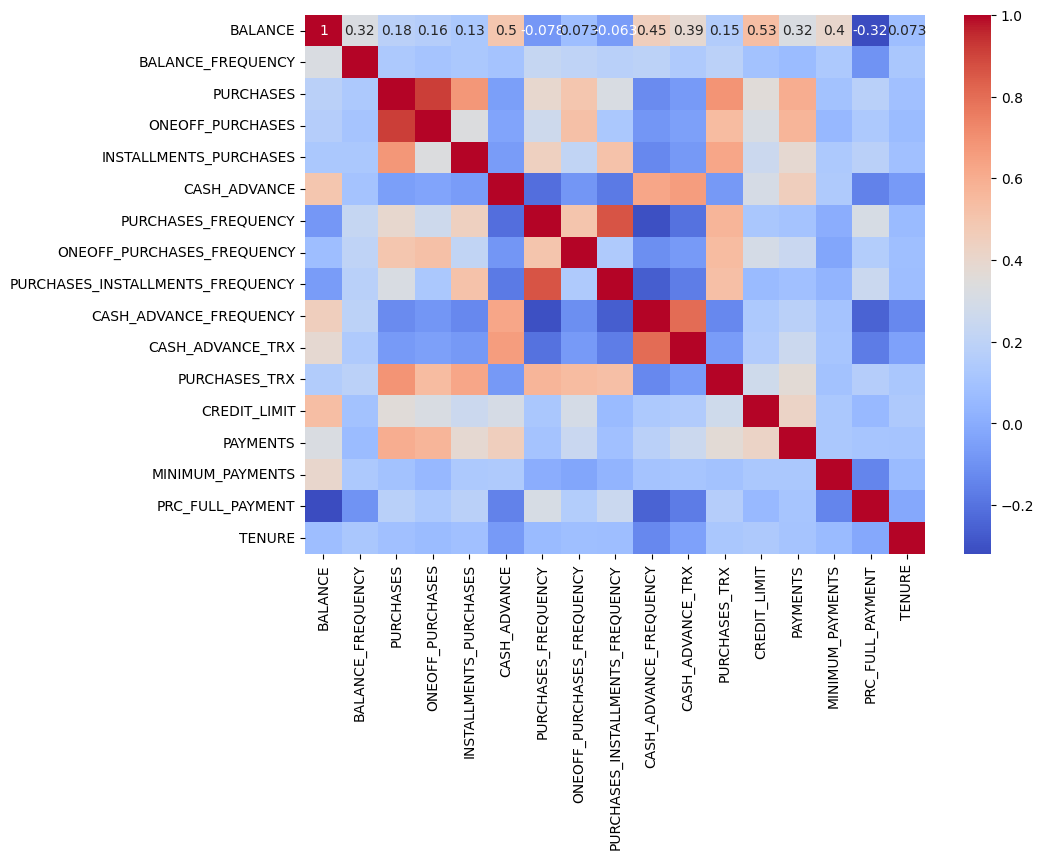

In [54]:
#Look for **correlations** between numeric features
plt.figure(figsize=(10,7))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.show()

## **2. Data Preparation**

In [ ]:
import numpy as np

#drop customer id
df = df.drop(columns=["CUST_ID"])

#drop the one missing entity in credit limit
df = df.dropna(subset=["CREDIT_LIMIT"])

#group by balance digit, and fill missing values with the median of the corresponding group
df["MINIMUM_PAYMENTS"].isnull().sum()
df["BALANCE_DIGITS"] = df["BALANCE"].apply(
    lambda x: len(str(int(abs(x)))) if x > 0 else 1
)
df["MINIMUM_PAYMENTS"] = df.groupby("BALANCE_DIGITS")[
    "MINIMUM_PAYMENTS"
].transform(lambda x: x.fillna(x.median()))


In [56]:
df["MINIMUM_PAYMENTS"].fillna(
    df["MINIMUM_PAYMENTS"].median(),
    inplace=True
)
df["MINIMUM_PAYMENTS"].isnull().sum()


C:\Users\ganna\AppData\Local\Temp\ipykernel_21900\4175627205.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["MINIMUM_PAYMENTS"].fillna(


0

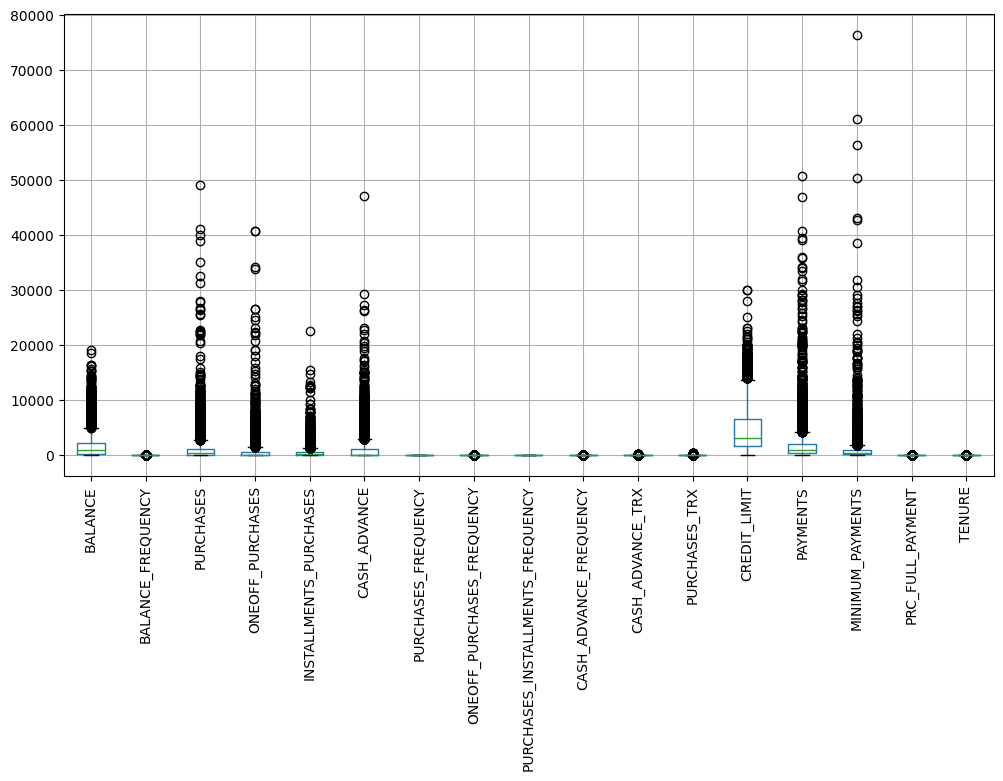

In [ ]:
#Identify **outliers** 
plt.figure(figsize=(12,6))
df[numeric_cols].boxplot(rot=90)
plt.show()

In [58]:
#  count outliers using IQR
def count_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = series[(series < lower_bound) | (series > upper_bound)]
    return len(outliers)

# apply to all numeric columns
outlier_counts = {}

for col in numeric_cols:
    outlier_counts[col] = count_outliers(df[col])

# convert to table
outlier_counts = pd.Series(outlier_counts).sort_values(ascending=False)

print(outlier_counts)

BALANCE_FREQUENCY                   1492
PRC_FULL_PAYMENT                    1474
TENURE                              1365
CASH_ADVANCE                        1030
ONEOFF_PURCHASES                    1013
MINIMUM_PAYMENTS                     894
INSTALLMENTS_PURCHASES               867
PAYMENTS                             808
PURCHASES                            808
CASH_ADVANCE_TRX                     804
ONEOFF_PURCHASES_FREQUENCY           782
PURCHASES_TRX                        766
BALANCE                              695
CASH_ADVANCE_FREQUENCY               525
CREDIT_LIMIT                         248
PURCHASES_FREQUENCY                    0
PURCHASES_INSTALLMENTS_FREQUENCY       0
dtype: int64


In [ ]:
#deature scaling 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

import pandas as pd

X_scaled = pd.DataFrame(
    X_scaled,
    columns=df.columns,
    index=df.index
)

In [ ]:
#verify scaling 

print("Average mean:", X_scaled.mean().mean())
print("Average std:", X_scaled.std().mean())

Average mean: -1.2306863788447368e-17
Average std: 1.0000558768474819


In [ ]:
#applying PCA to reduce dimention
from sklearn.decomposition import PCA

pca = PCA(n_components=0.90)   # keep 90% variance
X_pca = pca.fit_transform(X_scaled)

In [62]:
print("Original features:", X_scaled.shape[1])
print("PCA components:", X_pca.shape[1])


Original features: 18
PCA components: 10


## **3. Apply Agglomerative Clustering**

In [ ]:
#testing different Ks to choose the best
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

for k in range(2, 9):
    agg = AgglomerativeClustering(
        n_clusters=k,
        metric="euclidean",
        linkage="ward"
    )

    labels = agg.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)

    print(f"K = {k}, Silhouette Score = {score:.4f}")


K = 2, Silhouette Score = 0.1828
K = 3, Silhouette Score = 0.1703
K = 4, Silhouette Score = 0.1509
K = 5, Silhouette Score = 0.1655
K = 6, Silhouette Score = 0.1696
K = 7, Silhouette Score = 0.1841
K = 8, Silhouette Score = 0.1813


In [ ]:
#no. of points  in each cluster
from sklearn.cluster import AgglomerativeClustering
agg = AgglomerativeClustering(
    n_clusters=2,        
    metric="euclidean",
    linkage="ward"
)

labels = agg.fit_predict(X_pca)
df_analysis = df.copy()
df_analysis["Cluster"] = labels
df_analysis["Cluster"].value_counts()

Cluster
0    5801
1    3148
Name: count, dtype: int64

## **4. Visualize the Clustering Results**

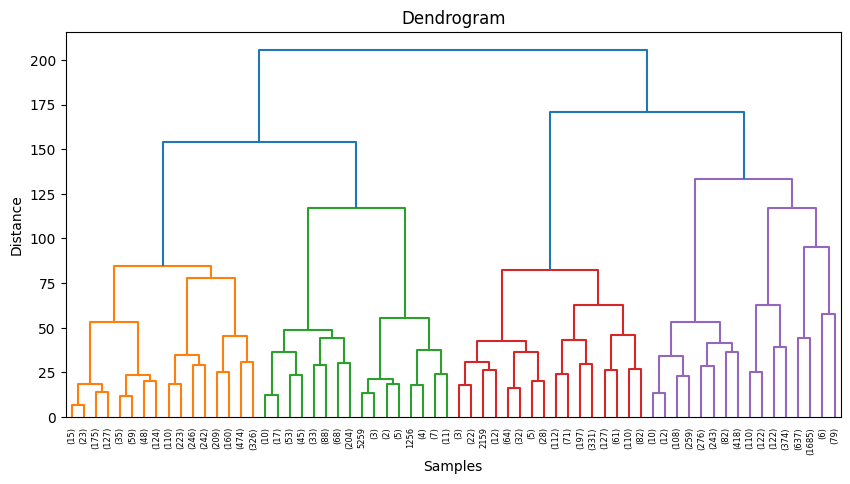

In [81]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

linked = linkage(X_pca, method="ward")

plt.figure(figsize=(10,5))
dendrogram(linked, truncate_mode='level', p=5)
plt.title("Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

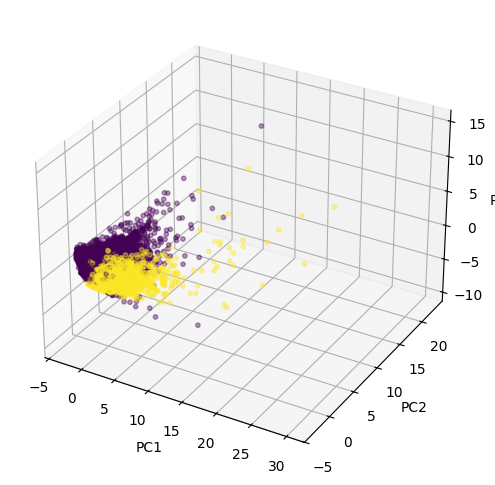

In [82]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2],
           c=labels, s=10, alpha=0.4)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.show()

## **5. Evaluate the Clustering**

In [83]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

for k in range(2, 9):
    agg = AgglomerativeClustering(
        n_clusters=k,
        metric="euclidean",
        linkage="ward"
    )

    labels = agg.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)

    print(f"K = {k}, Silhouette Score = {score:.4f}")

K = 2, Silhouette Score = 0.1828
K = 3, Silhouette Score = 0.1703
K = 4, Silhouette Score = 0.1509
K = 5, Silhouette Score = 0.1655
K = 6, Silhouette Score = 0.1696
K = 7, Silhouette Score = 0.1841
K = 8, Silhouette Score = 0.1813


## **6. Explain whether the clustering quality and justify your reasoning**

**The silhouette scores obtained were:**

K	:Silhouette Score

2 :	0.1828

7 :	0.1841 (highest)

Silhouette values range between −1 and 1:

> 0.5 → strong clustering

0.2 – 0.5 → reasonable structure

≈ 0 – 0.2 → weak but existing structure

Since the score is around 0.18, this indicates:

clusters exist

 separation between customers is not very strong.

 **Visualization in PCA Space**

When clusters were visualized using the first PCA components:


   clusters appeared close to each other


    boundaries were not clearly separated.


 This does not necessarily indicate failure, because:


     clustering was performed in higher-dimensional space


     PCA visualization is only a 2D projection


     separation may occur across multiple combined features